<a href="https://colab.research.google.com/github/Lidia-Kibret/Titanic-Analysis/blob/main/Financial%20Inclusion%20In%20Africa(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Financial Inclusion in Africa

## Dataset Overview

The Financial Inclusion in Africa dataset contains demographic, social, and economic information about individuals across different countries. It is used to understand and predict whether a person has access to a bank account.



## Objective

The goal of this project is to analyze the dataset and build a machine learning model that predicts financial inclusion status.

Specifically, the focus is on:

✔️ Understanding factors that influence bank account ownership

✔️ Exploring relationships between demographic features and financial access

✔️ Identifying patterns across countries and regions

✔️ Building a predictive model for classification



## Observations

✔️ The dataset contains both categorical and numerical features

✔️ The target variable is binary (bank account: Yes/No)

✔️ The dataset is imbalanced, with more individuals not having bank accounts

✔️ No missing values are present in the dataset

✔️ Features such as education level, job type, and cellphone access are important indicators of financial inclusion

- This step mounts Google Drive to access files within the Colab environment.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Data Loading

The dataset is loaded from Google Drive into pandas DataFrames.


## 1.1 Importing Libraries

The following libraries are used in this project:

- **pandas, numpy** → data manipulation and numerical operations  
- **seaborn, matplotlib** → data visualization  
- **scikit-learn** → preprocessing, model training, and evaluation  
- **XGBoost** → advanced machine learning model for classification  

In [6]:
# Data handling

import pandas as pd
import numpy as np
import math



# Visualization

import seaborn as sns
import matplotlib.pyplot as plt

# ML

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

from xgboost import XGBClassifier
from pandas_profiling import ProfileReport

import warnings
warnings.filterwarnings('ignore')

## 1.2 Load the CSV Files

- **Train dataset**: Contains features and target variable (`bank_account`)
- **Test dataset**: Contains only features (used for prediction)
- **Sample submission**: Shows required output format
- **Variable definitions**: Provides description of each feature

In [7]:
# Load files into pandas DataFrames

path = "/content/drive/MyDrive/Colab Notebooks/Data/"

train = pd.read_csv(path + "Train.csv")
test = pd.read_csv(path + "Test.csv")
ss = pd.read_csv(path + "SampleSubmission.csv")
variables = pd.read_csv(path + "VariableDefinitions.csv")




In [8]:
# Let us check the first five rows of the train dataset
train.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [9]:
# Lets us confirm the definitions of the features
var_def = pd.read_csv(path + "VariableDefinitions.csv")
var_def.columns = ["Variable", "Definition"]
var_def

,Variable,Definition
0,country,Country interviewee is in.
1,year,Year survey was done in.
2,uniqueid,Unique identifier for each interviewee
3,location_type,"Type of location: Rural, Urban"
4,cellphone_access,"If interviewee has access to a cellphone: Yes, No"
5,household_size,Number of people living in one house
6,age_of_respondent,The age of the interviewee
7,gender_of_respondent,"Gender of interviewee: Male, Female"
8,relationship_with_head,The interviewee’s relationship with the head o...
9,marital_status,The martial status of the interviewee: Married...


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB


In [11]:
train.nunique().sort_values(ascending=False).reset_index(name="uniqe_value")



,index,uniqe_value
0,uniqueid,8735
1,age_of_respondent,85
2,household_size,20
3,job_type,10
4,relationship_with_head,6
5,education_level,6
6,marital_status,5
7,country,4
8,year,3
9,location_type,2


In [12]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10086 entries, 0 to 10085
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 10086 non-null  object
 1   year                    10086 non-null  int64 
 2   uniqueid                10086 non-null  object
 3   location_type           10086 non-null  object
 4   cellphone_access        10086 non-null  object
 5   household_size          10086 non-null  int64 
 6   age_of_respondent       10086 non-null  int64 
 7   gender_of_respondent    10086 non-null  object
 8   relationship_with_head  10086 non-null  object
 9   marital_status          10086 non-null  object
 10  education_level         10086 non-null  object
 11  job_type                10086 non-null  object
dtypes: int64(3), object(9)
memory usage: 945.7+ KB


## Country Feature

In [13]:
train['country'].describe()

,country
count,23524
unique,4
top,Rwanda
freq,8735


In [14]:
train['country'].unique()

array(['Kenya', 'Rwanda', 'Tanzania', 'Uganda'], dtype=object)

In [15]:
train['country'].value_counts().reset_index(name="count")

,country,count
0,Rwanda,8735
1,Tanzania,6620
2,Kenya,6068
3,Uganda,2101


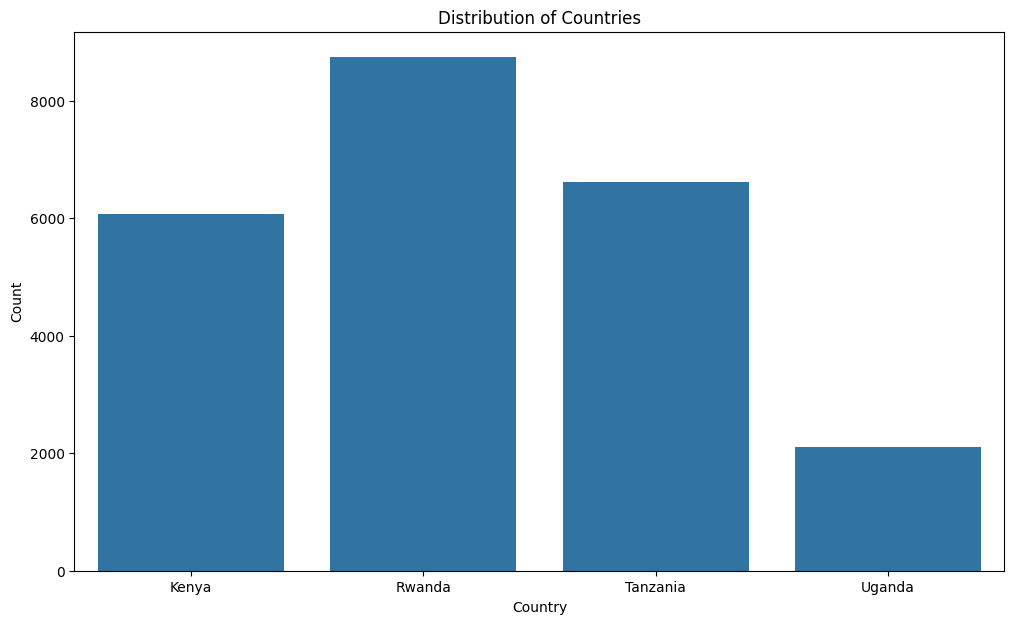

In [16]:
plt.figure(figsize=(12, 7))
sns.countplot(x='country', data=train)
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Distribution of Countries')
plt.show()

In [17]:
train.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


## Phone_Access Feature

In [18]:
train['cellphone_access'].describe()

,cellphone_access
count,23524
unique,2
top,Yes
freq,17454


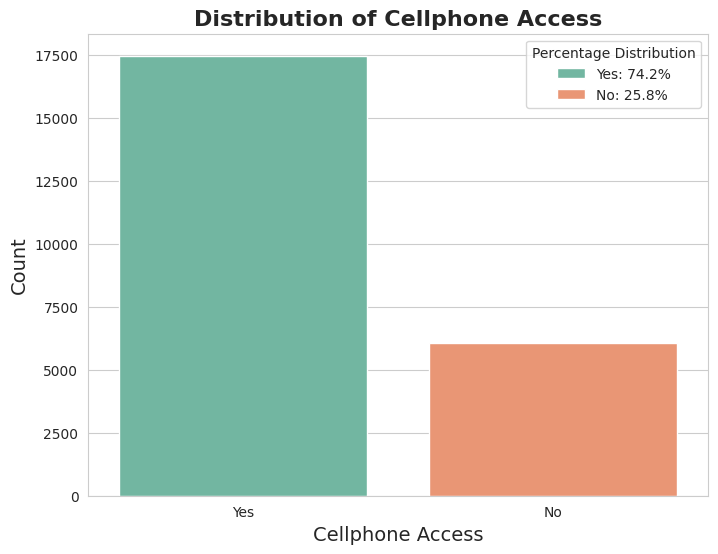

In [19]:
# Calculate percentage distribution
value_counts = train['cellphone_access'].value_counts()
percentages = (value_counts / value_counts.sum()) * 100

# Visualizing the distribution of values in the 'cellphone_access' column
plt.figure(figsize=(8, 6))
sns.set_style('whitegrid')

# Creating the countplot
sns.countplot(
    x='cellphone_access',
    data=train,
    palette='Set2'
)

# Adding labels and title
plt.xlabel('Cellphone Access', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Distribution of Cellphone Access', fontsize=16, fontweight='bold')

# Adding a legend with percentage distribution
legend_labels = [f'{label}: {percent:.1f}%' for label, percent in zip(value_counts.index, percentages)]
plt.legend(legend_labels, title='Percentage Distribution', loc='upper right')

# Display the plot
plt.show()


In [20]:
train.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


## Unique Id Feature

In [21]:
# Drop the 'uniqueid' column
train = train.drop(columns=['uniqueid'])

# Verify the column has been dropped
print(train.head())

  country  year bank_account location_type cellphone_access  household_size  \
0   Kenya  2018          Yes         Rural              Yes               3   
1   Kenya  2018           No         Rural               No               5   
2   Kenya  2018          Yes         Urban              Yes               5   
3   Kenya  2018           No         Rural              Yes               5   
4   Kenya  2018           No         Urban               No               8   

   age_of_respondent gender_of_respondent relationship_with_head  \
0                 24               Female                 Spouse   
1                 70               Female      Head of Household   
2                 26                 Male         Other relative   
3                 34               Female      Head of Household   
4                 26                 Male                  Child   

            marital_status                  education_level  \
0  Married/Living together              Secondary edu

In [22]:
## Education_Status

In [23]:
train['education_level'].describe()

,education_level
count,23524
unique,6
top,Primary education
freq,12791


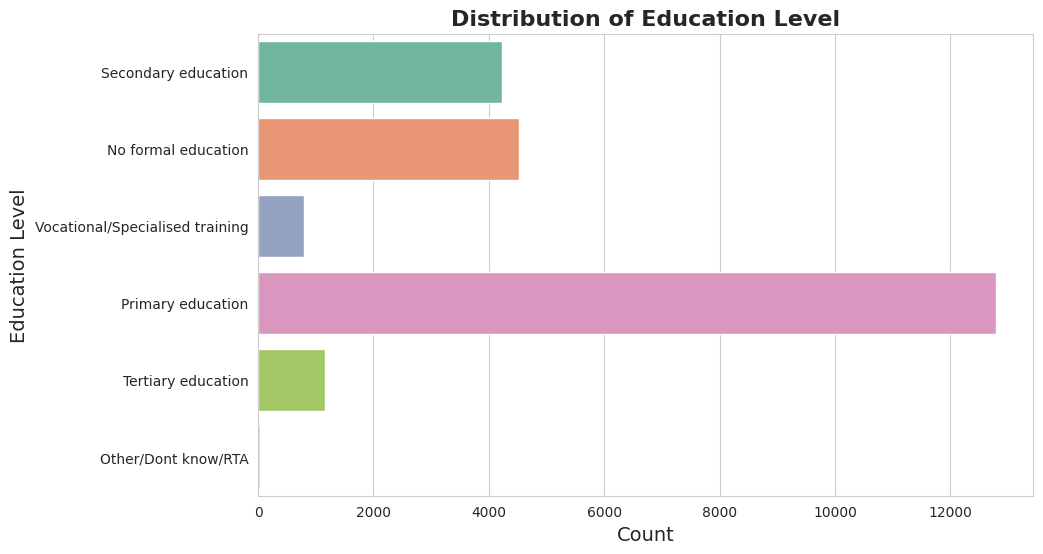

In [24]:
plt.figure(figsize=(10, 6))
sns.countplot(y='education_level', data=train, palette='Set2')

plt.xlabel('Count', fontsize=14)
plt.ylabel('Education Level', fontsize=14)
plt.title('Distribution of Education Level', fontsize=16, fontweight='bold')

plt.show()

In [25]:
train.head()

,country,year,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


## Job_Category

In [26]:
train['job_type'].describe()

,job_type
count,23524
unique,10
top,Self employed
freq,6437


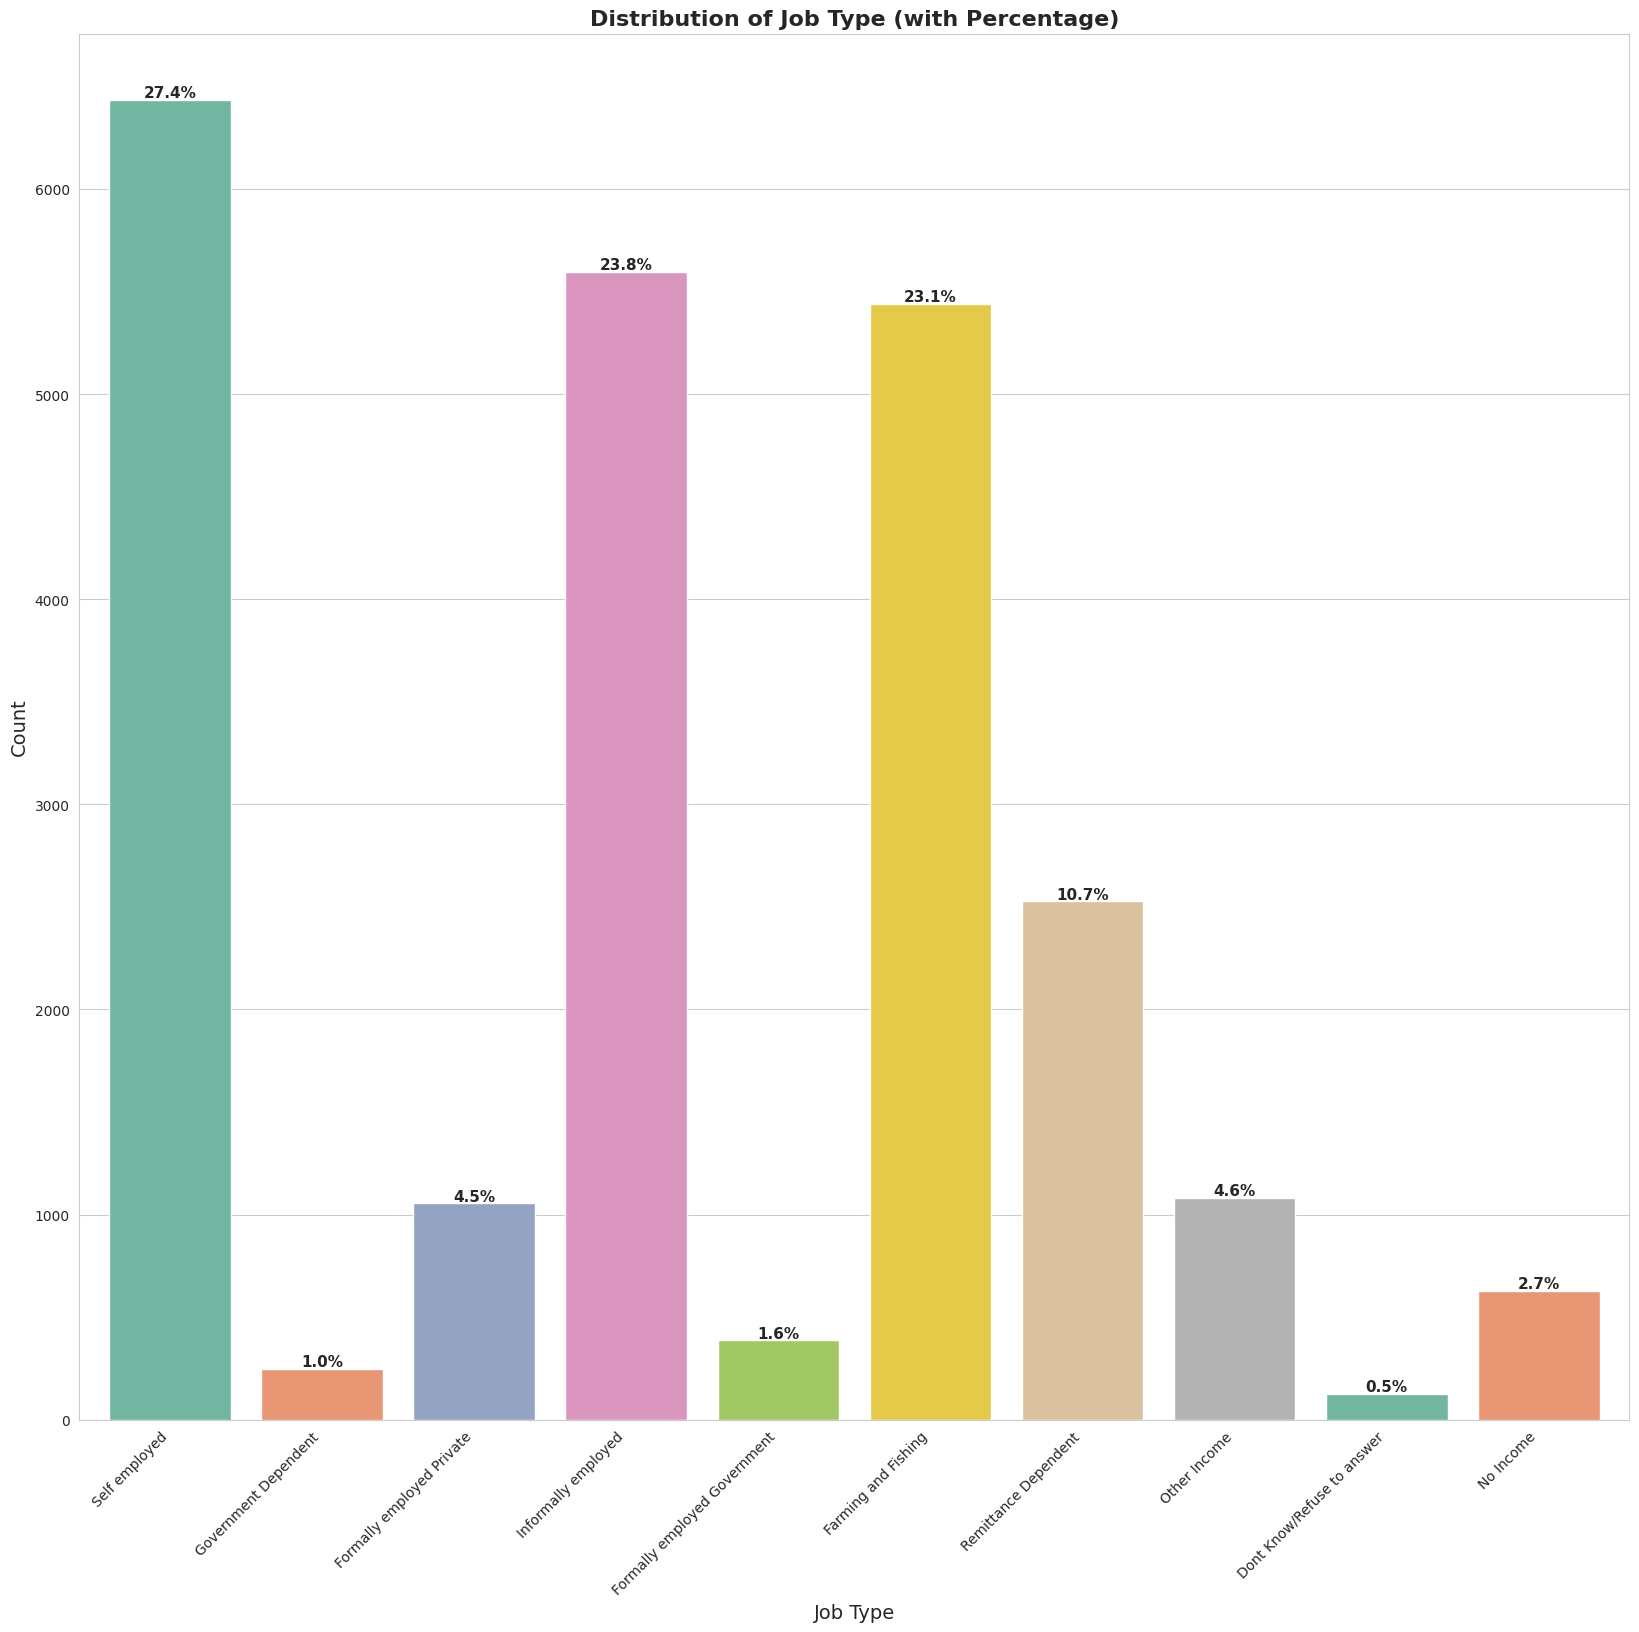

In [27]:
plt.figure(figsize=(20, 18))

value_counts = train['job_type'].value_counts()
percentages = (value_counts / value_counts.sum()) * 100

ax = sns.countplot(x='job_type', data=train, palette='Set2')

# Add percentages on bars
for p in ax.patches:
    height = p.get_height()
    percentage = (height / len(train)) * 100
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center',
                fontsize=11, fontweight='bold',
                xytext=(0, 5),
                textcoords='offset points')

# 📌 Improve x-axis spacing
plt.xticks(rotation=45, ha='right')   # 👈 key fix for space
plt.margins(x=0.02)                   # 👈 adds side spacing

plt.xlabel('Job Type', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Distribution of Job Type (with Percentage)', fontsize=16, fontweight='bold')

plt.show()

## Area_Type

In [28]:
train['location_type'].describe()

,location_type
count,23524
unique,2
top,Rural
freq,14343


In [29]:
train['location_type'].value_counts().reset_index(name="count")

,location_type,count
0,Rural,14343
1,Urban,9181


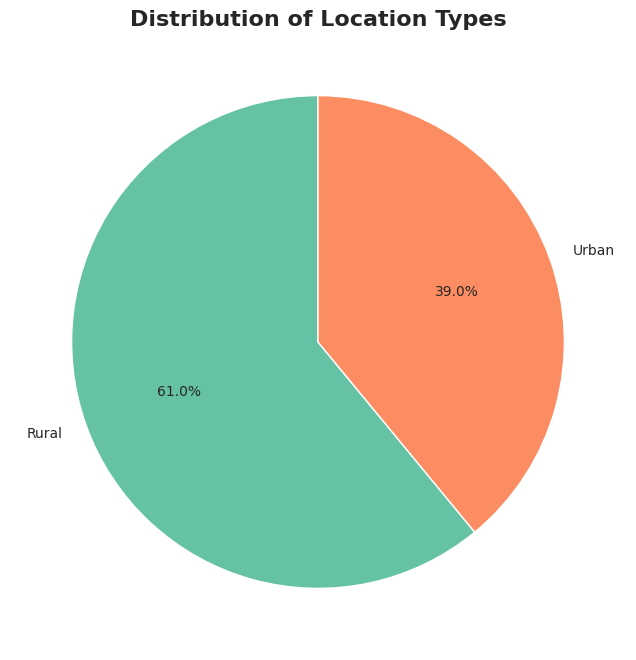

In [30]:
plt.figure(figsize=(8, 8))

location_counts = train['location_type'].value_counts()

plt.pie(
    location_counts,
    labels=location_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66c2a5', '#fc8d62']  # 👈 soft academic colors
)

plt.title('Distribution of Location Types', fontsize=16, fontweight='bold')
plt.show()

## Family_Size

In [31]:
train['household_size'].describe()

,household_size
count,23524.000000
mean,3.797483
std,2.227613
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,21.000000


In [32]:
train['household_size'].value_counts()

,count
household_size,
2,5229
3,3920
4,3474
1,3057
5,2853
6,2096
7,1400
8,751
9,363


In [33]:
print(train['household_size'].value_counts())
print(train['household_size'].value_counts().get(1, 0))
print(train['household_size'].value_counts().get(21, 0))

household_size
2     5229
3     3920
4     3474
1     3057
5     2853
6     2096
7     1400
8      751
9      363
10     190
11      69
12      68
13      25
15      11
14      10
16       4
21       1
18       1
17       1
20       1
Name: count, dtype: int64
3057
1


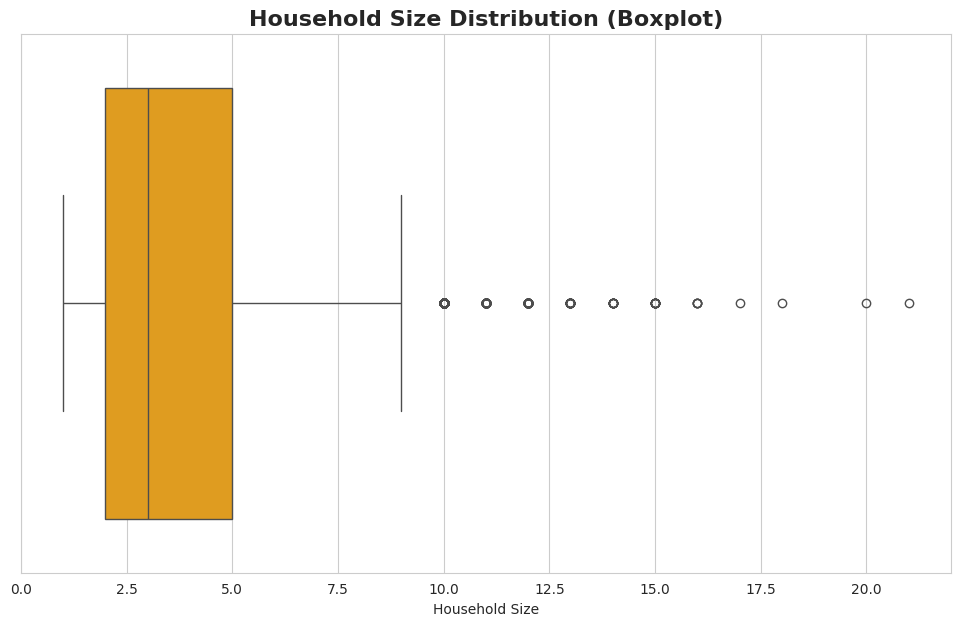

In [34]:
plt.figure(figsize=(12, 7))
sns.boxplot(x=train['household_size'], color='orange')

plt.title('Household Size Distribution (Boxplot)', fontsize=16, fontweight='bold')
plt.xlabel('Household Size')
plt.show()

In [35]:
# Define more readable bins
bins = [0, 2, 4, 6, 10, float('inf')]
labels = ['Small (1-2)', 'Medium (3-4)', 'Large (5-6)', 'Very Large (7-10)', 'Extreme (10+)']

# Apply binning
train['household_size_group'] = pd.cut(
    train['household_size'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Check distribution
train['household_size_group'].value_counts().reset_index(name="count")

,household_size_group,count
0,Small (1-2),8286
1,Medium (3-4),7394
2,Large (5-6),4949
3,Very Large (7-10),2704
4,Extreme (10+),191


In [36]:
train.head()

,country,year,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,household_size_group
0,Kenya,2018,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed,Medium (3-4)
1,Kenya,2018,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent,Large (5-6)
2,Kenya,2018,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed,Large (5-6)
3,Kenya,2018,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private,Large (5-6)
4,Kenya,2018,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed,Very Large (7-10)


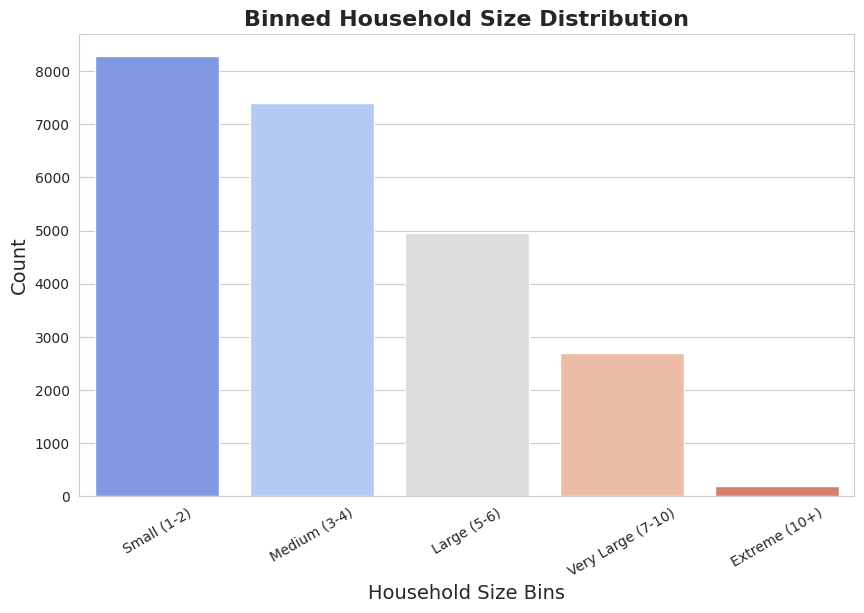

In [37]:
plt.figure(figsize=(10, 6))

order = train['household_size_group'].value_counts().index

sns.countplot(
    x='household_size_group',
    data=train,
    order=order,
    palette='coolwarm'
)

plt.xlabel('Household Size Bins', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Binned Household Size Distribution', fontsize=16, fontweight='bold')
plt.xticks(rotation=30)

plt.show()

In [38]:
# Dropping the household_size column
train = train.drop(columns=['household_size'])
train.head()

,country,year,bank_account,location_type,cellphone_access,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,household_size_group
0,Kenya,2018,Yes,Rural,Yes,24,Female,Spouse,Married/Living together,Secondary education,Self employed,Medium (3-4)
1,Kenya,2018,No,Rural,No,70,Female,Head of Household,Widowed,No formal education,Government Dependent,Large (5-6)
2,Kenya,2018,Yes,Urban,Yes,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed,Large (5-6)
3,Kenya,2018,No,Rural,Yes,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private,Large (5-6)
4,Kenya,2018,No,Urban,No,26,Male,Child,Single/Never Married,Primary education,Informally employed,Very Large (7-10)


In [39]:
bins = [0, 2, 4, 6, float('inf')]
labels = ['1-2', '3-4', '5-6', '7+']

test['household_size_group'] = pd.cut(
    test['household_size'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

#
print(test['household_size_group'].value_counts())


# Display the first few rows of the updated dataset
test.head()

household_size_group
1-2    3592
3-4    3130
5-6    2159
7+     1205
Name: count, dtype: int64


,country,year,uniqueid,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,household_size_group
0,Kenya,2018,uniqueid_6056,Urban,Yes,3,30,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government,3-4
1,Kenya,2018,uniqueid_6060,Urban,Yes,7,51,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private,7+
2,Kenya,2018,uniqueid_6065,Rural,No,3,77,Female,Parent,Married/Living together,No formal education,Remittance Dependent,3-4
3,Kenya,2018,uniqueid_6072,Rural,No,6,39,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent,5-6
4,Kenya,2018,uniqueid_6073,Urban,No,3,16,Male,Child,Single/Never Married,Secondary education,Remittance Dependent,3-4


In [40]:
# Dropping the household_size column
test = test.drop(columns=['household_size'])
test.head()

,country,year,uniqueid,location_type,cellphone_access,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,household_size_group
0,Kenya,2018,uniqueid_6056,Urban,Yes,30,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government,3-4
1,Kenya,2018,uniqueid_6060,Urban,Yes,51,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private,7+
2,Kenya,2018,uniqueid_6065,Rural,No,77,Female,Parent,Married/Living together,No formal education,Remittance Dependent,3-4
3,Kenya,2018,uniqueid_6072,Rural,No,39,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent,5-6
4,Kenya,2018,uniqueid_6073,Urban,No,16,Male,Child,Single/Never Married,Secondary education,Remittance Dependent,3-4


## Individual_Age Feature

In [41]:
train['age_of_respondent'].describe()

,age_of_respondent
count,23524.000000
mean,38.805220
std,16.520569
min,16.000000
25%,26.000000
50%,35.000000
75%,49.000000
max,100.000000


In [42]:
train['age_of_respondent'].value_counts().reset_index(name="count")

,age_of_respondent,count
0,30,1056
1,35,836
2,25,792
3,28,748
4,32,715
...,...,...
80,91,5
81,93,4
82,96,3
83,99,2


<Axes: xlabel='age_of_respondent', ylabel='Count'>

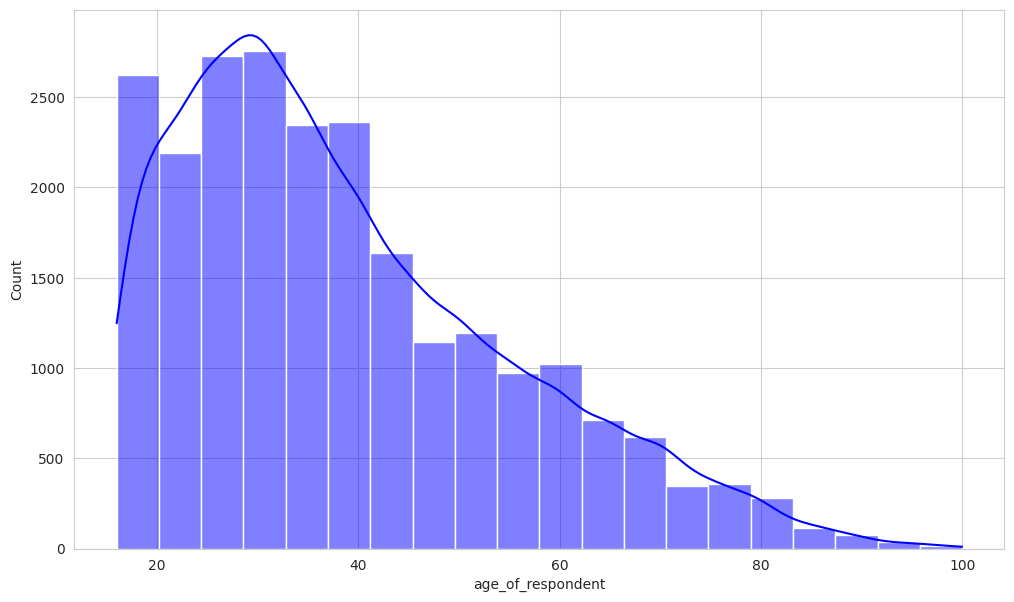

In [43]:
plt.figure(figsize=(12, 7))
sns.histplot(train['age_of_respondent'], bins=20, kde=True, color='blue')

<Axes: xlabel='age_of_respondent'>

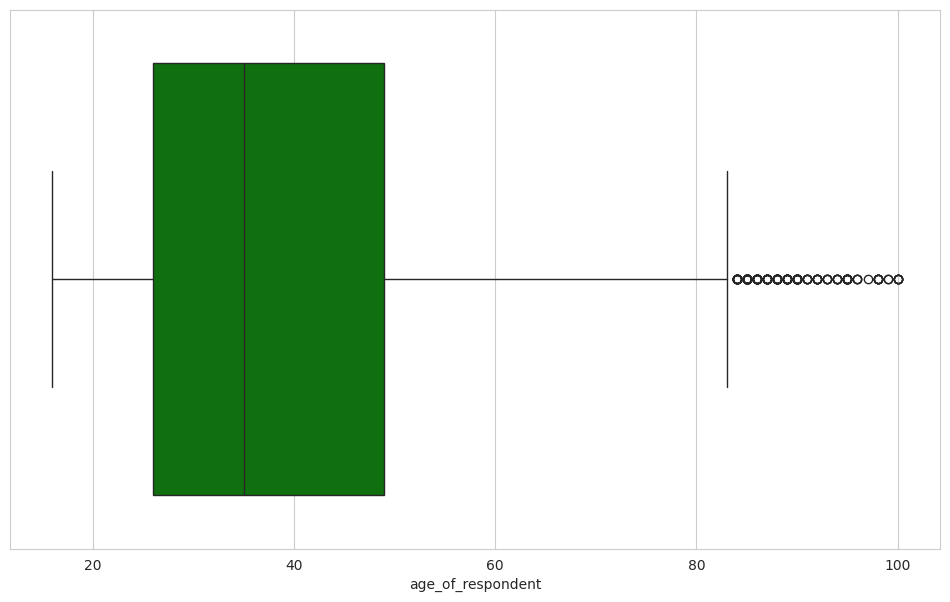

In [44]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='age_of_respondent', data=train, color='green')

In [45]:
# Apply logarithmic scaling
train['age_of_respondent_log'] = np.log1p(train['age_of_respondent'])  # np.log1p handles log(0) safely

# Display the transformed column
print(train[['age_of_respondent', 'age_of_respondent_log']].head())

   age_of_respondent  age_of_respondent_log
0                 24               3.218876
1                 70               4.262680
2                 26               3.295837
3                 34               3.555348
4                 26               3.295837


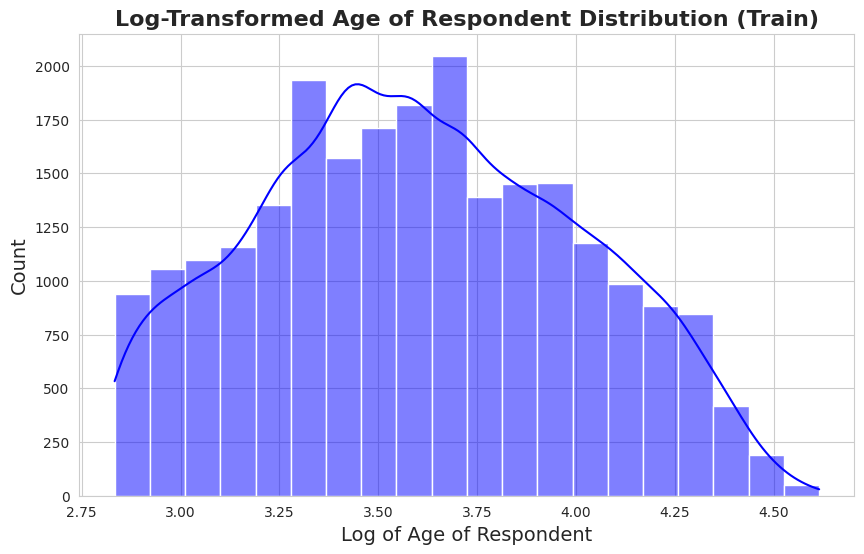

In [46]:
# Visualize the log-transformed household sizes
plt.figure(figsize=(10, 6))
sns.histplot(train['age_of_respondent_log'], kde=True, color='blue', bins=20)
plt.xlabel('Log of Age of Respondent', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Log-Transformed Age of Respondent Distribution (Train)', fontsize=16, fontweight='bold')
plt.show()

In [47]:
train = train.drop(columns=['age_of_respondent'])
train.head()

,country,year,bank_account,location_type,cellphone_access,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,household_size_group,age_of_respondent_log
0,Kenya,2018,Yes,Rural,Yes,Female,Spouse,Married/Living together,Secondary education,Self employed,Medium (3-4),3.218876
1,Kenya,2018,No,Rural,No,Female,Head of Household,Widowed,No formal education,Government Dependent,Large (5-6),4.262680
2,Kenya,2018,Yes,Urban,Yes,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed,Large (5-6),3.295837
3,Kenya,2018,No,Rural,Yes,Female,Head of Household,Married/Living together,Primary education,Formally employed Private,Large (5-6),3.555348
4,Kenya,2018,No,Urban,No,Male,Child,Single/Never Married,Primary education,Informally employed,Very Large (7-10),3.295837


   age_of_respondent  age_of_respondent_log
0                 30               3.433987
1                 51               3.951244
2                 77               4.356709
3                 39               3.688879
4                 16               2.833213


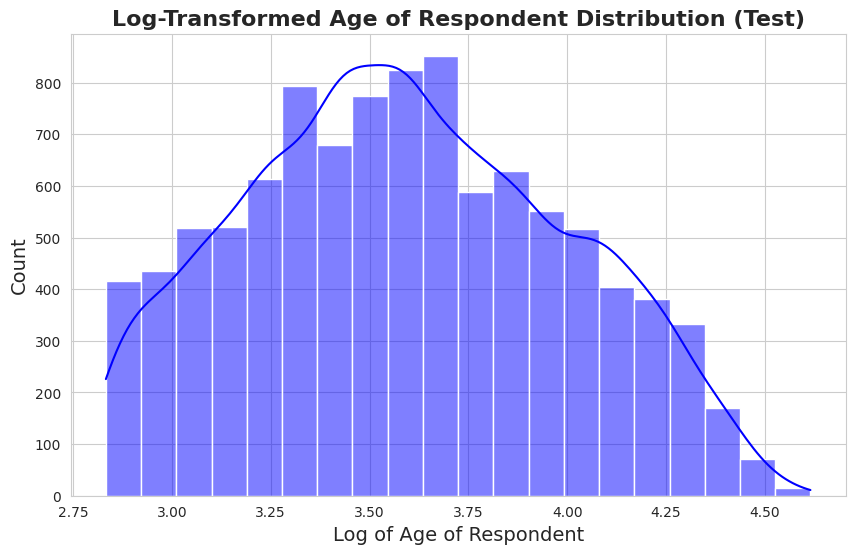

In [48]:
# Apply logarithmic scaling
test['age_of_respondent_log'] = np.log1p(test['age_of_respondent'])  # np.log1p handles log(0) safely

# Display the transformed column
print(test[['age_of_respondent', 'age_of_respondent_log']].head())

# Visualize the log-transformed household sizes
plt.figure(figsize=(10, 6))
sns.histplot(test['age_of_respondent_log'], kde=True, color='blue', bins=20)
plt.xlabel('Log of Age of Respondent', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Log-Transformed Age of Respondent Distribution (Test)', fontsize=16, fontweight='bold')
plt.show()

In [49]:
# Dropping the age_of_respondent column
test = test.drop(columns=['age_of_respondent'])
test.head()

,country,year,uniqueid,location_type,cellphone_access,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,household_size_group,age_of_respondent_log
0,Kenya,2018,uniqueid_6056,Urban,Yes,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government,3-4,3.433987
1,Kenya,2018,uniqueid_6060,Urban,Yes,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private,7+,3.951244
2,Kenya,2018,uniqueid_6065,Rural,No,Female,Parent,Married/Living together,No formal education,Remittance Dependent,3-4,4.356709
3,Kenya,2018,uniqueid_6072,Rural,No,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent,5-6,3.688879
4,Kenya,2018,uniqueid_6073,Urban,No,Male,Child,Single/Never Married,Secondary education,Remittance Dependent,3-4,2.833213


## ➡️ EDA Insights

## ✔️ Country

- The dataset includes Kenya, Rwanda, Tanzania, and Uganda. There are noticeable differences across countries, which may affect financial inclusion levels.


## Cellphone Access

- Most respondents have access to mobile phones, showing that mobile technology is widely available and important for financial services.


## Household Size

- Household sizes range from 1 to 21, but most are between 2–5 members. Extreme values were grouped into bins to improve modeling.


## Education Level

- Most respondents have primary or secondary education, while fewer have no education or higher education. Education is likely a key factor in financial inclusion.


## Job Type

- Self-employment and informal jobs dominate the dataset, suggesting many people work outside formal employment systems.


## Location Type

- A majority of respondents live in rural areas, which may limit access to banking services.


## Age

Ages range widely, with most between 25–50 years. A log transformation was applied to reduce skewness.

## ➡️ Key Takeaways

- Rural residence and informal jobs reduce financial inclusion

- Mobile phone access is high and important

- Education and employment strongly influence bank account ownership

- Data was cleaned using binning and log transformation for better modeling

## Occupation_Education

In [50]:
train['job_education'] = train['job_type'] + '_' + train['education_level']

In [51]:
test['job_education'] = test['job_type'] + '_' + test['education_level']

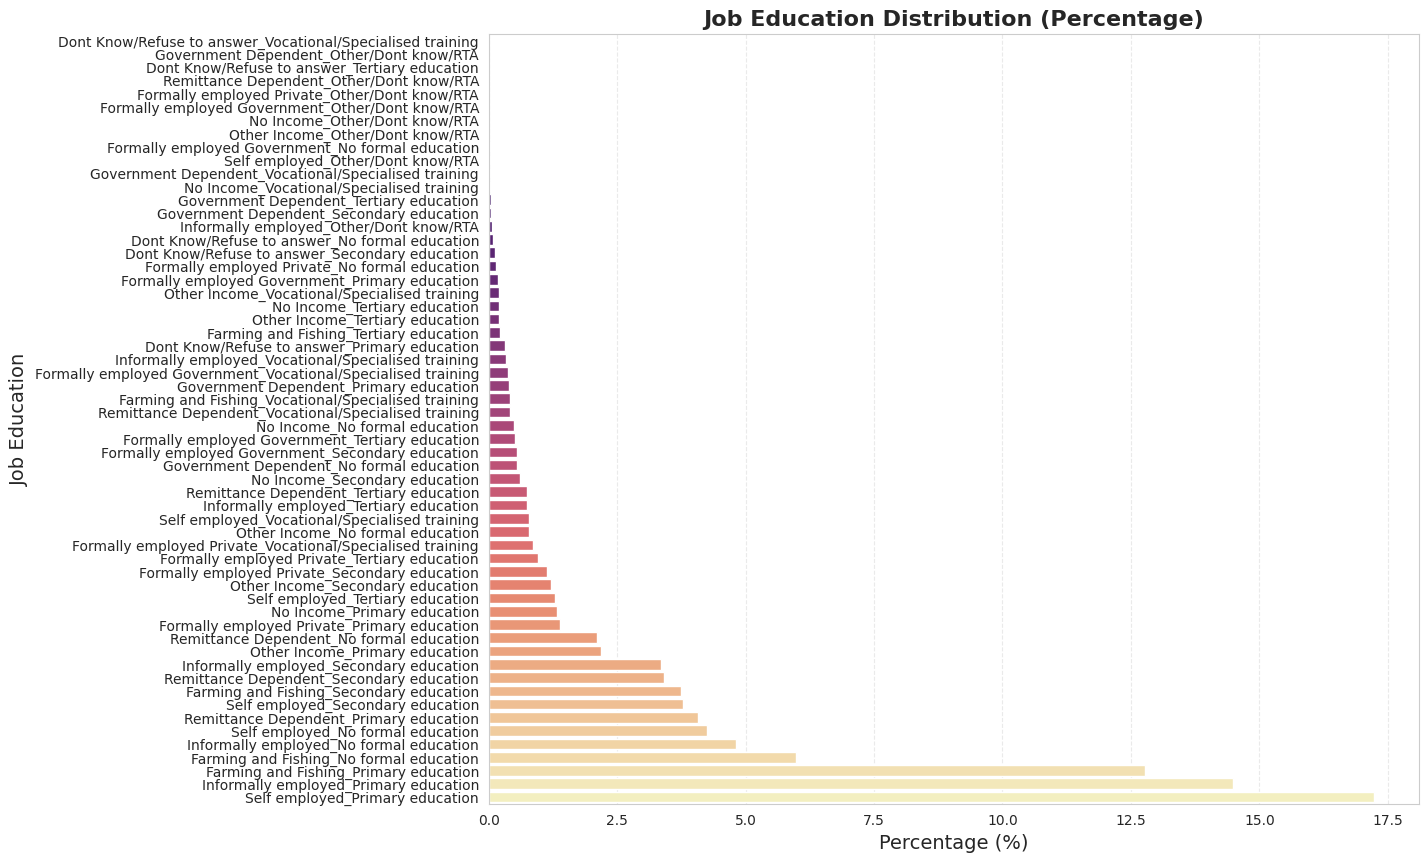

In [52]:
# Calculate percentage distribution
job_edu_counts = train['job_education'].value_counts()
job_edu_percentages = (job_edu_counts / job_edu_counts.sum()) * 100

# Create DataFrame for plotting
job_edu_df = job_edu_percentages.reset_index()
job_edu_df.columns = ['job_education', 'percentage']

# Sort for better visualization
job_edu_df = job_edu_df.sort_values('percentage', ascending=True)

# Plot horizontal bar chart (better readability for long categories)
plt.figure(figsize=(12, 10))

sns.barplot(
    data=job_edu_df,
    x='percentage',
    y='job_education',
    palette='magma'   # different color style
)

# Add labels and title
plt.xlabel('Percentage (%)', fontsize=14)
plt.ylabel('Job Education', fontsize=14)
plt.title('Job Education Distribution (Percentage)', fontsize=16, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

In [53]:
train.head()

,country,year,bank_account,location_type,cellphone_access,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,household_size_group,age_of_respondent_log,job_education
0,Kenya,2018,Yes,Rural,Yes,Female,Spouse,Married/Living together,Secondary education,Self employed,Medium (3-4),3.218876,Self employed_Secondary education
1,Kenya,2018,No,Rural,No,Female,Head of Household,Widowed,No formal education,Government Dependent,Large (5-6),4.262680,Government Dependent_No formal education
2,Kenya,2018,Yes,Urban,Yes,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed,Large (5-6),3.295837,Self employed_Vocational/Specialised training
3,Kenya,2018,No,Rural,Yes,Female,Head of Household,Married/Living together,Primary education,Formally employed Private,Large (5-6),3.555348,Formally employed Private_Primary education
4,Kenya,2018,No,Urban,No,Male,Child,Single/Never Married,Primary education,Informally employed,Very Large (7-10),3.295837,Informally employed_Primary education


## Geographic_Area

In [54]:
train['geographical_location'] = train['country'] + '_' + train['location_type']


In [55]:
test['geographical_location'] = test['country'] + '_' + test['location_type']

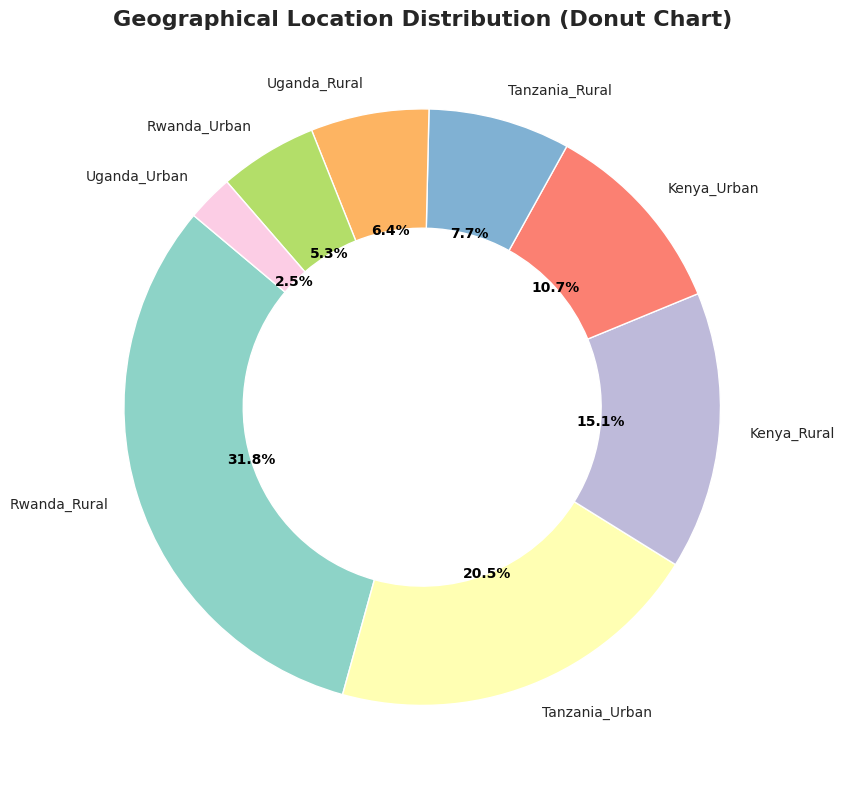

In [56]:
# Calculate percentage distribution
geo_counts = train['geographical_location'].value_counts()
geo_percentages = (geo_counts / geo_counts.sum()) * 100

# Create donut chart
plt.figure(figsize=(10, 8))

colors = sns.color_palette('Set3', len(geo_counts))  # new color palette

wedges, texts, autotexts = plt.pie(
    geo_percentages,
    labels=geo_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'width': 0.4}  # 👈 makes it a donut
)

# Style percentage text
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

# Title
plt.title('Geographical Location Distribution (Donut Chart)', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

In [57]:
train.head()

,country,year,bank_account,location_type,cellphone_access,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,household_size_group,age_of_respondent_log,job_education,geographical_location
0,Kenya,2018,Yes,Rural,Yes,Female,Spouse,Married/Living together,Secondary education,Self employed,Medium (3-4),3.218876,Self employed_Secondary education,Kenya_Rural
1,Kenya,2018,No,Rural,No,Female,Head of Household,Widowed,No formal education,Government Dependent,Large (5-6),4.262680,Government Dependent_No formal education,Kenya_Rural
2,Kenya,2018,Yes,Urban,Yes,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed,Large (5-6),3.295837,Self employed_Vocational/Specialised training,Kenya_Urban
3,Kenya,2018,No,Rural,Yes,Female,Head of Household,Married/Living together,Primary education,Formally employed Private,Large (5-6),3.555348,Formally employed Private_Primary education,Kenya_Rural
4,Kenya,2018,No,Urban,No,Male,Child,Single/Never Married,Primary education,Informally employed,Very Large (7-10),3.295837,Informally employed_Primary education,Kenya_Urban


## Demographic_Group

In [58]:
train['age_gender'] = train['age_of_respondent_log'].astype(str) + '_' + train['gender_of_respondent']

In [59]:
test['age_gender'] = test['age_of_respondent_log'].astype(str) + '_' + test['gender_of_respondent']

In [60]:
train.head()

,country,year,bank_account,location_type,cellphone_access,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,household_size_group,age_of_respondent_log,job_education,geographical_location,age_gender
0,Kenya,2018,Yes,Rural,Yes,Female,Spouse,Married/Living together,Secondary education,Self employed,Medium (3-4),3.218876,Self employed_Secondary education,Kenya_Rural,3.2188758248682006_Female
1,Kenya,2018,No,Rural,No,Female,Head of Household,Widowed,No formal education,Government Dependent,Large (5-6),4.262680,Government Dependent_No formal education,Kenya_Rural,4.2626798770413155_Female
2,Kenya,2018,Yes,Urban,Yes,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed,Large (5-6),3.295837,Self employed_Vocational/Specialised training,Kenya_Urban,3.295836866004329_Male
3,Kenya,2018,No,Rural,Yes,Female,Head of Household,Married/Living together,Primary education,Formally employed Private,Large (5-6),3.555348,Formally employed Private_Primary education,Kenya_Rural,3.5553480614894135_Female
4,Kenya,2018,No,Urban,No,Male,Child,Single/Never Married,Primary education,Informally employed,Very Large (7-10),3.295837,Informally employed_Primary education,Kenya_Urban,3.295836866004329_Male


In [61]:
train.columns

Index(['country', 'year', 'bank_account', 'location_type', 'cellphone_access',
       'gender_of_respondent', 'relationship_with_head', 'marital_status',
       'education_level', 'job_type', 'household_size_group',
       'age_of_respondent_log', 'job_education', 'geographical_location',
       'age_gender'],
      dtype='object')

## Model

In [62]:
train['bank_account'] = train['bank_account'].map({'No': 0, 'Yes': 1})
train['bank_account'].value_counts()

,count
bank_account,
0,20212
1,3312


In [63]:

# One hot encoding the categorical columns and splitting the dataset into train and test sets
from sklearn.model_selection import train_test_split

# Identify categorical columns that need one-hot encoding
categorical_columns = [
    'country', 'location_type', 'cellphone_access', 'gender_of_respondent',
    'relationship_with_head', 'marital_status', 'education_level', 'job_type',
    'household_size_group', 'geographical_location', 'age_gender', 'job_education'
]

# One-hot encode the categorical columns (do not include numerical ones)
train = pd.get_dummies(train, columns=categorical_columns, drop_first=True) # Drop first to avoid multicollinearity

# Step 3: Separate features (X) and target (y)
X = train.drop(columns=['bank_account'])  # Features (exclude target variable)
y = train['bank_account']  # Target (bank_account)

# Step 4: Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

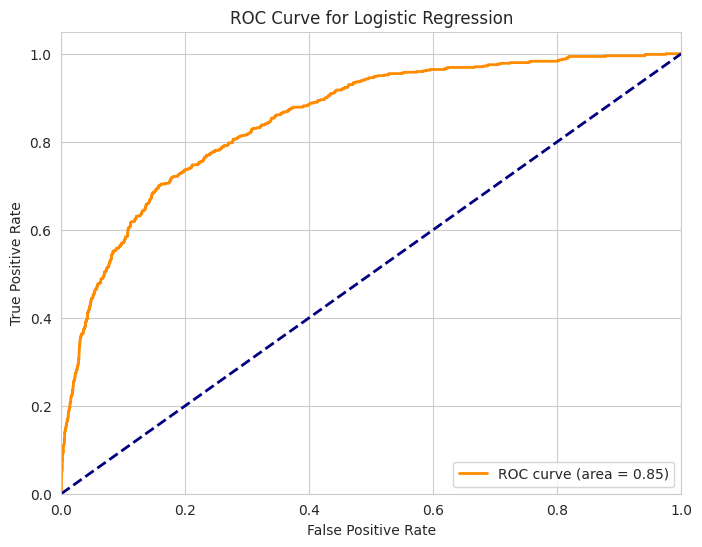

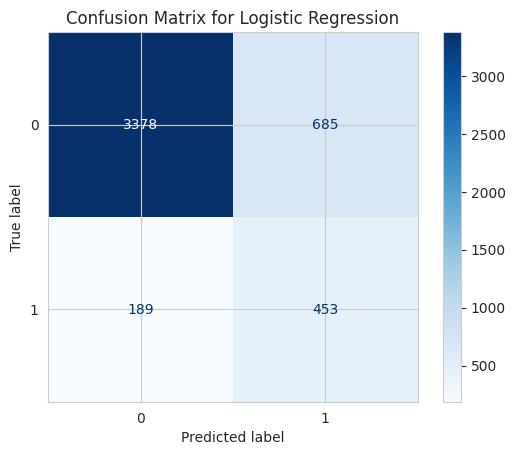

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.95      0.83      0.89      4063
           1       0.40      0.71      0.51       642

    accuracy                           0.81      4705
   macro avg       0.67      0.77      0.70      4705
weighted avg       0.87      0.81      0.83      4705



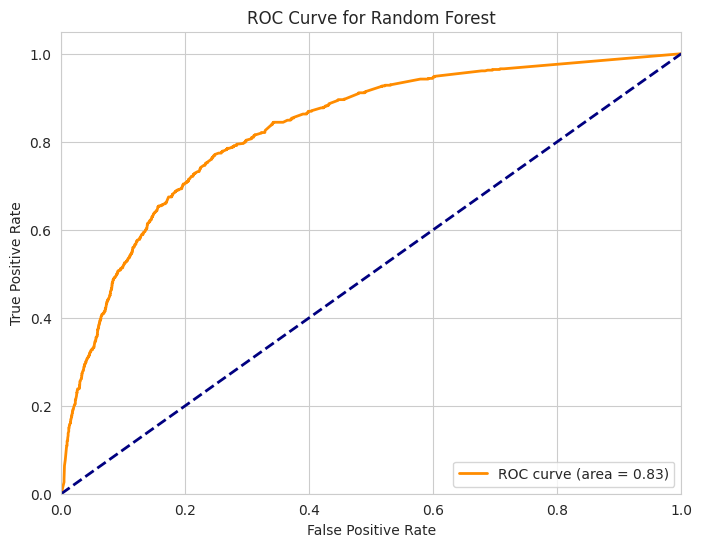

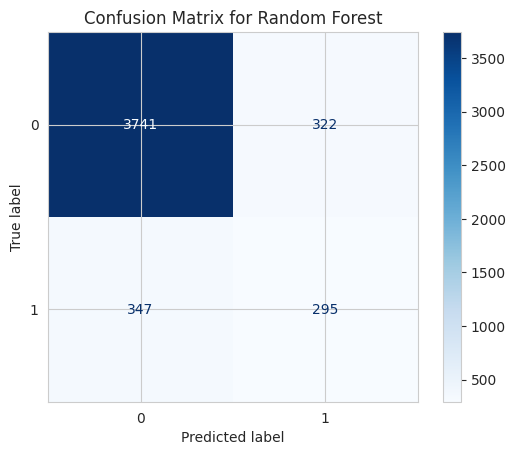

Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      4063
           1       0.48      0.46      0.47       642

    accuracy                           0.86      4705
   macro avg       0.70      0.69      0.69      4705
weighted avg       0.86      0.86      0.86      4705



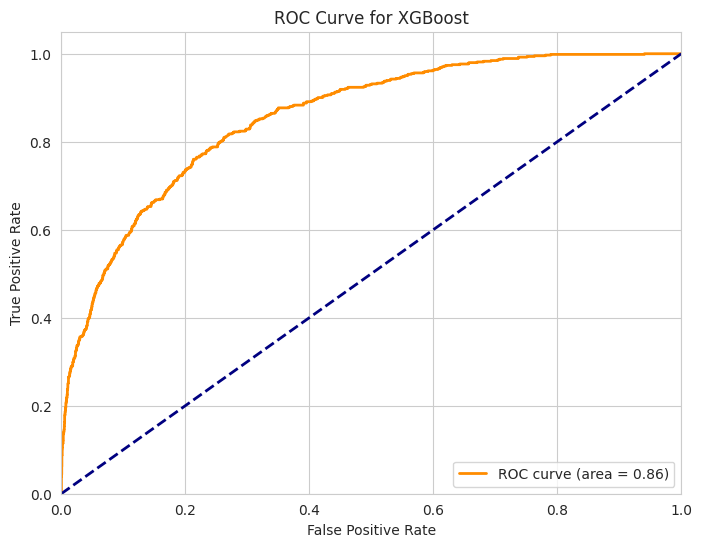

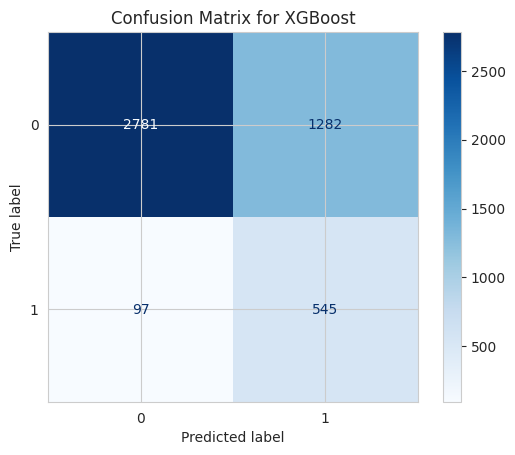

Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.97      0.68      0.80      4063
           1       0.30      0.85      0.44       642

    accuracy                           0.71      4705
   macro avg       0.63      0.77      0.62      4705
weighted avg       0.88      0.71      0.75      4705

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.814240   0.398067  0.705607  0.508989  0.851727
1        Random Forest  0.857811   0.478120  0.459502  0.468626  0.827956
2              XGBoost  0.706908   0.298303  0.848910  0.441474  0.855386


In [64]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from sklearn.metrics import ConfusionMatrixDisplay


# Step 1: Apply SMOTE to oversample the minority class in the training data
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# Step 2: Define a function to evaluate models and display results
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # Fit the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    roc_auc = auc(fpr, tpr)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {model_name}')
    plt.legend(loc='lower right')
    plt.show()

    # Plot Confusion Matrix
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
    cm_display.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

    # Print Classification Report
    print(f"Classification Report for {model_name}:\n")
    print(classification_report(y_test, y_pred))

    # Return performance metrics
    return accuracy, precision, recall, f1, roc_auc

# Step 3: Logistic Regression with class weights
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg_results = evaluate_model(log_reg, X_res, y_res, X_test, y_test, 'Logistic Regression')

# Step 4: Random Forest with class weights
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_results = evaluate_model(rf, X_res, y_res, X_test, y_test, 'Random Forest')

# Step 5: XGBoost with class weights
xgb_model = xgb.XGBClassifier(scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]), random_state=42)
xgb_results = evaluate_model(xgb_model, X_res, y_res, X_test, y_test, 'XGBoost')

# Step 6: Summarize Results
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [log_reg_results[0], rf_results[0], xgb_results[0]],
    'Precision': [log_reg_results[1], rf_results[1], xgb_results[1]],
    'Recall': [log_reg_results[2], rf_results[2], xgb_results[2]],
    'F1 Score': [log_reg_results[3], rf_results[3], xgb_results[3]],
    'ROC AUC': [log_reg_results[4], rf_results[4], xgb_results[4]]
}

# Convert to DataFrame for easy visualization
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

In [65]:
print(X_train.dtypes)

year                                                             int64
age_of_respondent_log                                          float64
country_Rwanda                                                    bool
country_Tanzania                                                  bool
country_Uganda                                                    bool
                                                                ...   
job_education_Self employed_Other/Dont know/RTA                   bool
job_education_Self employed_Primary education                     bool
job_education_Self employed_Secondary education                   bool
job_education_Self employed_Tertiary education                    bool
job_education_Self employed_Vocational/Specialised training       bool
Length: 266, dtype: object
